# **AQI Forecasting System (Air Quality Index Predictor)**

---

## **Executive Summary**

This project focuses on building an end-to-end time-series forecasting system to predict the **Air Quality Index (AQI)** for the next 72 hours (3 days). Unlike standard regression problems, AQI forecasting requires strict temporal awareness, where predictions must rely exclusively on past observations to avoid data leakage.

The system integrates environmental data, including pollutant concentrations (PM2.5, PM10, NO₂, CO, O₃) and weather variables such as temperature, humidity, and wind speed. These features capture the dynamic interactions that influence air quality over time.

A structured workflow is followed, including time-series exploratory analysis, feature engineering (lag features, rolling statistics, and calendar variables), and model development using both linear and tree-based algorithms. The system ensures proper temporal validation using time-aware splitting techniques and supports multi-step forecasting using a recursive approach.

The final solution is designed with production considerations, including automated data pipelines, feature storage, model versioning, and API-based deployment. It enables applications such as pollution monitoring, public health alerts, and environmental decision-making.

---

## **1. Problem Definition**

### Objective
Predict future AQI values based on historical environmental data.

### Target Variable
- PM2.5 (continuous numerical value)

### Forecast Horizon
- Next 72 hours (3 days ahead)

### Prediction Type
- Multi-step time-series forecasting

### Forecasting Strategy
- Recursive forecasting:
  - Predict next step → feed prediction back → predict further

---

## **2. Business Context**

Air pollution poses significant risks to public health and urban sustainability. Accurate AQI forecasting supports:

- Public health advisories  
- Outdoor activity planning  
- Government pollution control strategies  
- Environmental monitoring systems  

---

## **3. ML Formulation**

### A) Forecasting → Regression Problem
Predict AQI values (continuous) using historical data and external features.

### B) Time-Series Constraints

Unlike traditional ML:

- Data must be processed sequentially  
- Future data must NEVER influence past predictions  
- Validation must respect temporal ordering  

---

## **4. Critical Time-Series Considerations**

### Temporal Dependency
AQI depends on past pollution levels and weather conditions.

### Data Leakage (Critical Risk)
Using future information during training leads to unrealistic performance.

Example of leakage:
- Using AQI(t+1) to predict AQI(t)

### Why Random Train-Test Split is Incorrect
- Random splitting mixes past and future data
- Causes leakage and inflated performance

### Correct Approach
- Time-based split  
- Train on past → test on future  

---

## **5. Methodology Overview**

The project follows a production-oriented workflow:

1. Data Collection  
   - Fetch real-time and historical data from APIs  

2. Feature Engineering  
   - Lag features (past AQI values)  
   - Rolling statistics (mean, std)  
   - Time-based features (hour, day, month)  

3. Model Development  
   - Train regression models (Linear, Tree-based)  

4. Temporal Validation  
   - Use time-aware validation (e.g., TimeSeriesSplit)  

5. Multi-Step Forecasting  
   - Generate predictions for the next 72 hours  

6. Backtesting  
   - Evaluate model performance over rolling time windows  

7. Deployment Preparation  
   - Build pipelines for automation and serving  

---

## **6. Input Features**

### Pollution Features
- PM2.5, PM10  
- NO₂, CO, O₃  

### Weather Features
- Temperature  
- Humidity  
- Wind speed  

### Engineered Features (to be created)
- Lag features (AQI history)  
- Rolling statistics  
- Time-based features  

---

## **7. Success Metrics**

### Primary Metric
- **MAE (Mean Absolute Error)**  
  Measures average prediction error in AQI units  

### Secondary Metrics
- **RMSE (Root Mean Squared Error)**  
- **R² Score**

### Evaluation Strategy
- Time-based validation  
- Backtesting across multiple periods  
- Stability across different pollution conditions  

---

## **8. Final Output**

The system produces:

- AQI forecast for next 72 hours  
- Evaluation metrics (MAE, RMSE, R²)  
- Historical vs predicted comparison  
- AQI category labels (Good, Moderate, Unhealthy)  

---

## **9. Project Goal**

To develop a production-ready AQI forecasting system that accurately predicts short-term air quality using time-aware machine learning techniques, enabling better public health awareness and environmental decision-making.

---

## **10. Dataset Description**

Data is collected from external APIs such as AQICN or OpenWeather.

### Key Characteristics
- Granularity: Hourly or daily observations  
- Source: Environmental APIs  
- Time span: Historical + real-time streaming  

### Features
- datetime  
- aqi (target)  
- pm2_5, pm10  
- no2, co, o3  
- temperature  
- humidity  
- wind_speed  

---

## Importing Libraries

In [97]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests

## Data Acquisition

In [98]:
res = requests.get("http://api.waqi.info/feed/karachi/?token=846fd19da16057b2b05f49f426d993bf082d4db3")
data = res.json()

In [99]:
data

{'status': 'ok',
 'data': {'aqi': 161,
  'idx': 11790,
  'attributions': [{'url': 'https://pk.usembassy.gov/',
    'name': 'Pakistan Air Quality Monitor - US EPA',
    'logo': 'US-StateDepartment.png'},
   {'url': 'https://waqi.info/', 'name': 'World Air Quality Index Project'}],
  'city': {'geo': [24.8415, 67.0091],
   'name': 'Karachi US Consulate, Pakistan',
   'url': 'https://aqicn.org/city/pakistan/karachi/us-consulate',
   'location': ''},
  'dominentpol': 'pm25',
  'iaqi': {'dew': {'v': -19},
   'h': {'v': 3},
   'p': {'v': 1016},
   'pm25': {'v': 161},
   't': {'v': 31},
   'w': {'v': 5.1}},
  'time': {'s': '2025-03-04 16:00:00',
   'tz': '+05:00',
   'v': 1741104000,
   'iso': '2025-03-04T16:00:00+05:00'},
  'forecast': {'daily': {'o3': [{'avg': 15,
      'day': '2025-03-02',
      'max': 48,
      'min': 6},
     {'avg': 19, 'day': '2025-03-03', 'max': 23, 'min': 17},
     {'avg': 13, 'day': '2025-03-04', 'max': 36, 'min': 4},
     {'avg': 15, 'day': '2025-03-05', 'max': 52, 

This API response is a current station-level AQI snapshot plus short pollutant forecasts, wrapped in a nested JSON structure.

Since the API only gives us the current AQI, we will now import an AQI dataset downloaded from kaggle for model training

In [100]:
df = pd.read_excel('./data/PRSA_Data_Aotizhongxin_20130301-20170228.xlsx')
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [101]:
df.drop('No', axis=1, inplace=True)

In [102]:
df.describe()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,1.708496
std,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,1.204071
min,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,2017.000000,12.000000,31.000000,23.000000,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


PM2.5 is selected as the target variable as it is the dominant pollutant influencing AQI.

While AQI depends on multiple pollutants, PM2.5 is used as a proxy due to:
- its strong correlation with AQI
- its availability in both dataset and API

Other pollutants are excluded from the model as they are not consistently available in real-time API data.

The model will therefore learn to predict PM2.5 using past values and weather-related features.

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     35064 non-null  int64  
 1   month    35064 non-null  int64  
 2   day      35064 non-null  int64  
 3   hour     35064 non-null  int64  
 4   PM2.5    34139 non-null  float64
 5   PM10     34346 non-null  float64
 6   SO2      34129 non-null  float64
 7   NO2      34041 non-null  float64
 8   CO       33288 non-null  float64
 9   O3       33345 non-null  float64
 10  TEMP     35044 non-null  float64
 11  PRES     35044 non-null  float64
 12  DEWP     35044 non-null  float64
 13  RAIN     35044 non-null  float64
 14  wd       34983 non-null  object 
 15  WSPM     35050 non-null  float64
 16  station  35064 non-null  object 
dtypes: float64(11), int64(4), object(2)
memory usage: 4.5+ MB


In [104]:
df.isna().sum()

year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

## Data Transformation

Merging year, month, day, hour into one datetime field

In [105]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

In [106]:
cols = ['datetime'] + [col for col in df.columns if col != 'datetime']
df = df[cols]
df = df.sort_values(by='datetime')
df.head()

,datetime,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013-03-01 00:00:00,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2013-03-01 01:00:00,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,2013-03-01 03:00:00,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [107]:
df['station'].value_counts()

station
Aotizhongxin    35064
Name: count, dtype: int64

Since the station field is constant, we will drop it

In [108]:
df = df.drop('station', axis=1)

We will also drop the records where PM2.5 is missing, as that is our target feature

In [109]:
df = df.dropna(subset=['PM2.5'], ignore_index=True)

In [110]:
df.isna().sum()

datetime       0
year           0
month          0
day            0
hour           0
PM2.5          0
PM10           9
SO2          282
NO2          363
CO          1115
O3          1067
TEMP          20
PRES          20
DEWP          20
RAIN          20
wd            81
WSPM          14
dtype: int64

For the remaining missing values we will use forward fill and backward fill. Forward fill will replace middle and end missing values, and backward fill will fill the initial missing values

In [111]:
df = df.ffill()
df = df.bfill()

In [112]:
df.isna().sum()

datetime    0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
dtype: int64

---

## EDA

Let us now explore the trend of PM2.5 overtime

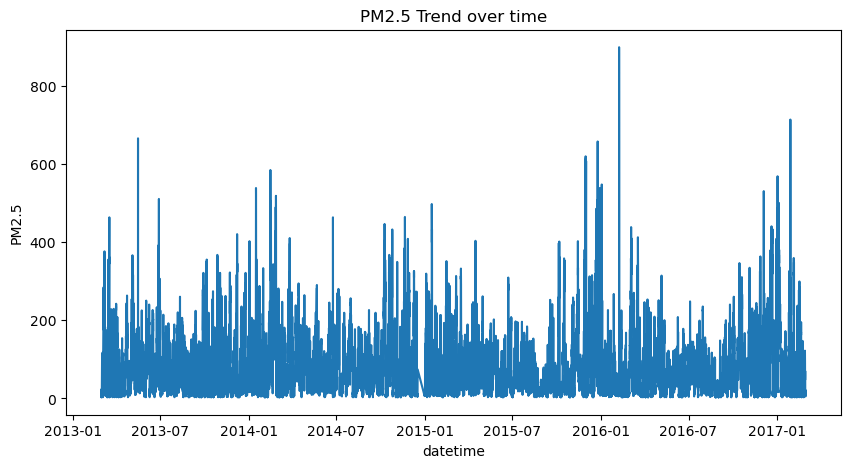

In [113]:
plt.figure(figsize=(10,5))
plt.title('PM2.5 Trend over time')
sns.lineplot(data=df, x='datetime', y='PM2.5')
plt.show()

The PM2.5 time-series exhibits high volatility with frequent extreme spikes, indicating a non-stationary and high-variance process. The dense hourly observations result in an overcrowded visualization, masking underlying temporal patterns. This suggests the need for smoothing techniques such as rolling averages to reveal trend and seasonality, and highlights that the model must be capable of handling sudden fluctuations rather than relying solely on smooth trends.

Let us now observe rolling average per day

In [114]:
df['pm25_rolling_24'] = df['PM2.5'].rolling(window=24).mean()

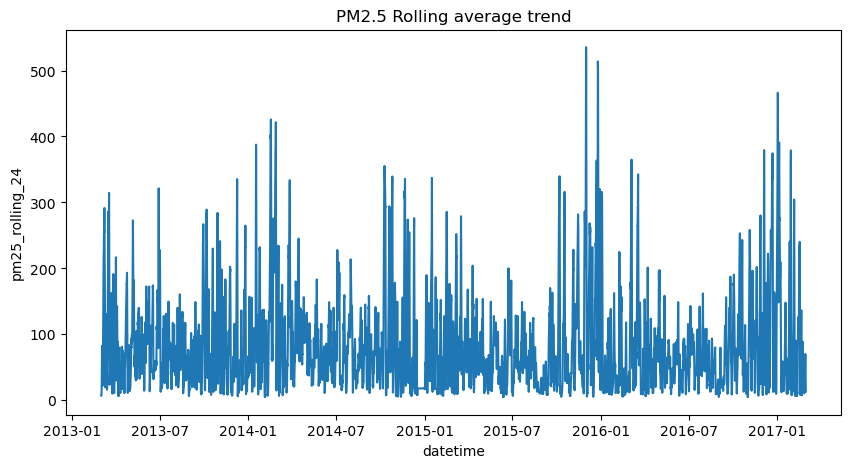

In [115]:
plt.figure(figsize=(10,5))
plt.title('PM2.5 Rolling average trend')
sns.lineplot(data=df, x='datetime', y='pm25_rolling_24')
plt.show()

24-hour averaging removes hourly noise, but the data is still quite volatile day-to-day. This means we need a larger window (like a week) to see clearer trends.

Let us observe a 7 day rolling average

In [116]:
df['pm25_rolling_168'] = df['PM2.5'].rolling(window=168).mean()

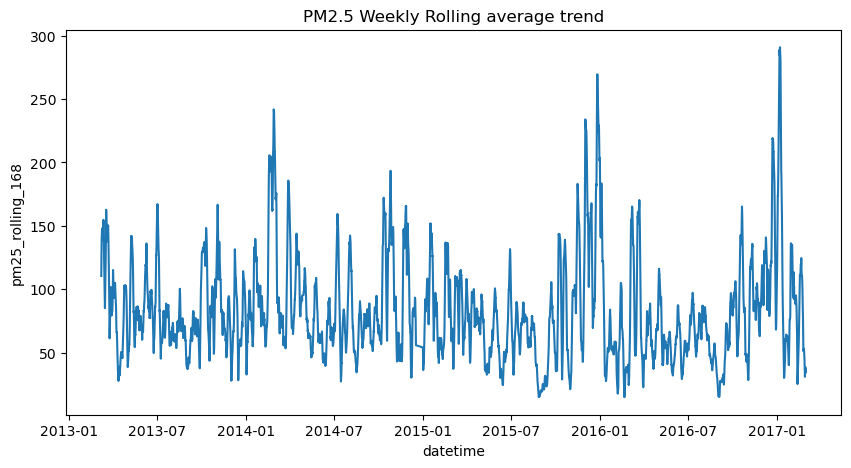

In [117]:
plt.figure(figsize=(10,5))
plt.title('PM2.5 Weekly Rolling average trend')
sns.lineplot(data=df, x='datetime', y='pm25_rolling_168')
plt.show()

After smoothing, PM2.5 shows a baseline around 50–100 with occasional spikes above 200. There are periods of sustained higher pollution, suggesting seasonal patterns.

Now we will observe the average PM2.5 per hour of the day

In [118]:
hourly_pattern = df.groupby('hour')['PM2.5'].mean().reset_index()

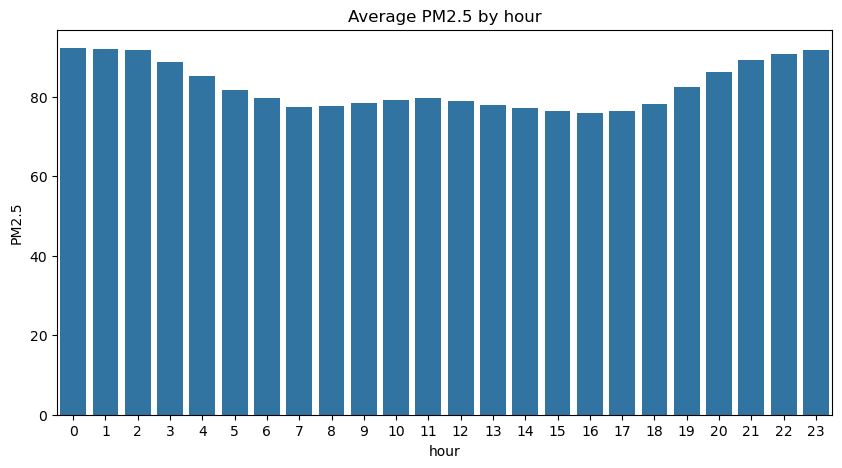

In [119]:
plt.figure(figsize=(10,5))
plt.title('Average PM2.5 by hour')
sns.barplot(data=hourly_pattern, x='hour', y='PM2.5')
plt.show()

PM2.5 levels are highest during late night and evening hours, and lowest during midday. This suggests a clear daily cycle where pollution accumulates at night and disperses during the day.

Now we will observe average PM2.5 by month

In [120]:
monthly_pattern = df.groupby('month')['PM2.5'].mean().reset_index()

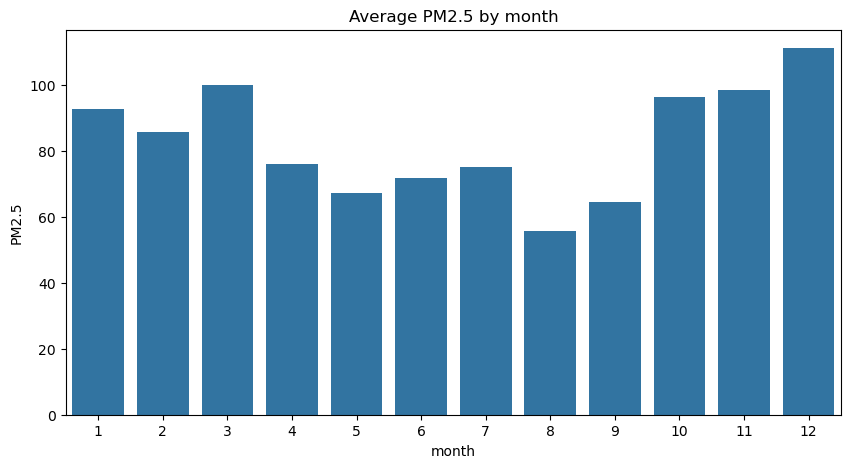

In [121]:
plt.figure(figsize=(10,5))
plt.title('Average PM2.5 by month')
sns.barplot(data=monthly_pattern, x='month', y='PM2.5')
plt.show()

PM2.5 levels are highest in winter months (Nov–Feb) and lowest in summer (Jun–Aug). Pollution decreases from spring into summer and rises again in fall, showing strong seasonal patterns.

Now let us observe correlations between features

In [122]:
df.corr(numeric_only=True)['PM2.5'].sort_values(ascending=False)

PM2.5               1.000000
PM10                0.876796
CO                  0.784403
pm25_rolling_24     0.753350
NO2                 0.682179
SO2                 0.481636
pm25_rolling_168    0.294948
DEWP                0.120309
month               0.025505
day                 0.007920
PRES               -0.005879
hour               -0.010388
RAIN               -0.014003
year               -0.030612
TEMP               -0.129145
O3                 -0.164759
WSPM               -0.278739
Name: PM2.5, dtype: float64

In [123]:
df.head()

,datetime,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,pm25_rolling_24,pm25_rolling_168
0,2013-03-01 00:00:00,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,NaN,NaN
1,2013-03-01 01:00:00,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,NaN,NaN
2,2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,NaN,NaN
3,2013-03-01 03:00:00,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,NaN,NaN
4,2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,NaN,NaN


In [124]:
df.isna().sum()

datetime              0
year                  0
month                 0
day                   0
hour                  0
PM2.5                 0
PM10                  0
SO2                   0
NO2                   0
CO                    0
O3                    0
TEMP                  0
PRES                  0
DEWP                  0
RAIN                  0
wd                    0
WSPM                  0
pm25_rolling_24      23
pm25_rolling_168    167
dtype: int64